In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_excel("Online Retail.xlsx")

print(df.head())
print(df.shape)

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
(541909, 8)


In [3]:
df.dropna(inplace=True)

df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

In [4]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

customer_data = df.groupby('CustomerID').agg({
    'InvoiceNo': 'nunique',
    'Quantity': 'sum',
    'TotalAmount': 'sum'
})

customer_data.columns = [
    'TotalPurchases',
    'TotalQuantity',
    'TotalSpent'
]

print(customer_data.head())

            TotalPurchases  TotalQuantity  TotalSpent
CustomerID                                           
12346.0                  1          74215    77183.60
12347.0                  7           2458     4310.00
12348.0                  4           2341     1797.24
12349.0                  1            631     1757.55
12350.0                  1            197      334.40


In [5]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(customer_data)

In [6]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.79099936 0.1833084 ]


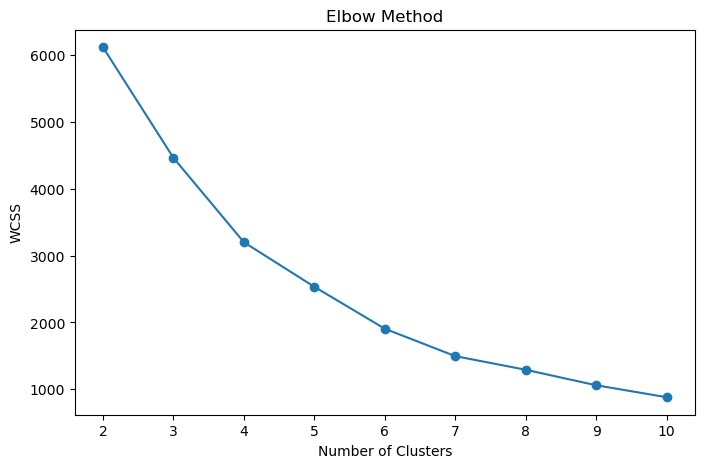

In [7]:
wcss = []

for i in range(2,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(pca_data)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [8]:
for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(pca_data)

    score = silhouette_score(
        pca_data,
        labels
    )

    print(f"K={k}, Silhouette Score={score:.4f}")

K=2, Silhouette Score=0.9623
K=3, Silhouette Score=0.8138
K=4, Silhouette Score=0.7688
K=5, Silhouette Score=0.8152
K=6, Silhouette Score=0.7532
K=7, Silhouette Score=0.6703
K=8, Silhouette Score=0.6305
K=9, Silhouette Score=0.6529
K=10, Silhouette Score=0.6006


In [9]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(pca_data)

customer_data['Cluster'] = clusters

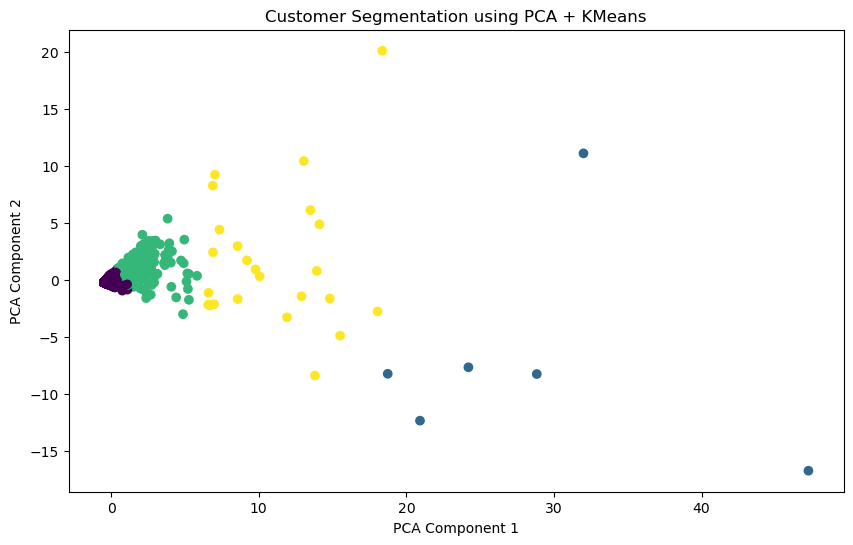

In [10]:
plt.figure(figsize=(10,6))

plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=clusters,
    cmap='viridis'
)

plt.title("Customer Segmentation using PCA + KMeans")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.show()

In [11]:
cluster_summary = customer_data.groupby(
    'Cluster'
).mean()

print(cluster_summary)

         TotalPurchases  TotalQuantity     TotalSpent
Cluster                                              
0              2.803283     586.009596     980.466365
1             67.166667   94944.666667  195271.033333
2             16.238506    4159.017241    7521.479253
3             57.375000   34592.000000   51652.505000
